In [1]:
from dotenv import load_dotenv
import os

load_dotenv()  # reads .env file from the current directory
LOCAL: bool = False

In [2]:
from pyspark.sql import SparkSession

try:
    from databricks.connect import DatabricksSession

    spark = DatabricksSession.builder.getOrCreate()
except Exception as e:
    print("Error creating DatabricksSession:", e)
    spark = SparkSession.builder.getOrCreate()
    LOCAL = True
    print("Fallback to SparkSession successful")

Error creating DatabricksSession: No module named 'databricks'


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/17 16:26:27 WARN Utils: Your hostname, jtv, resolves to a loopback address: 127.0.1.1; using 10.77.231.78 instead (on interface wlp192s0)
26/05/17 16:26:27 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/17 16:26:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Fallback to SparkSession successful


## constants

In [3]:
schema = "`safety-pvprototypes_bronze_dev`.safety_surveillance"

if LOCAL:
    path_narratives = f"data/faers/faers_narratives_small"
else:
    path_narratives = (
        f"/Volumes/safety-pvprototypes_bronze_dev/safety_surveillance/filesets/faers/narratives/faers_narratives"
    )


SEQUENCE_SEPARATOR = "<|endoftext|>"  # [EOS]

DEFAULT_VOCABULARY_SIZE = 50257
DEFAULT_EMBEDDINGS_DIMENSION = 256
DEFAULT_SEQUENCE_LENGTH = 4
DEFAULT_STRIDE = 1

## functions

In [4]:
from datetime import datetime, timezone
from pyspark.sql import functions as F, DataFrame
from delta.tables import DeltaTable
from pyspark.errors import AnalysisException
import torch

torch.manual_seed(123)

In [5]:
from pyspark.sql import functions as F, Window


def create_drug_sections(drug_table: str) -> DataFrame:
    df_drug = spark.table(drug_table)

    # --- role_cod human-readable mapping ---
    role_map = {
        "PS": "primary suspect",
        "SS": "secondary suspect",
        "C": "concomitant",
        "I": "interacting",
    }

    # --- 1. aggregate drugs per case ---
    df_drugs_agg = (
        df_drug.withColumn(
            "drug_desc",
            F.concat_ws(
                " ",
                F.upper(F.col("drugname")),
                F.when(F.col("dose_vbm").isNotNull(), F.concat(F.lit("("), F.col("dose_vbm"), F.lit(")"))),
                F.when(F.col("route").isNotNull(), F.concat(F.lit("via "), F.lower(F.col("route")))),
            ),
        )
        .withColumn(
            "role_desc",
            F.coalesce(
                F.create_map(*[item for kv in role_map.items() for item in (F.lit(kv[0]), F.lit(kv[1]))])[
                    F.col("role_cod")
                ],
                F.col("role_cod"),
            ),
        )
        .withColumn("drug_text", F.concat(F.col("drug_desc"), F.lit(" ["), F.col("role_desc"), F.lit("]")))
        .groupBy("primaryid")
        .agg(F.concat_ws("; ", F.collect_list("drug_text")).alias("drugs_text"))
    )

    return df_drugs_agg


def create_reaction_sections(reactions_table: str) -> DataFrame:
    df_reactions = spark.table(reactions_table)

    # --- 2. aggregate reactions per case ---
    df_reac_agg = (
        df_reactions.withColumn(
            "reac_text",
            F.concat_ws(
                " ",
                F.lower(F.col("pt")),
                F.when(F.col("pt_code").isNotNull(), F.concat(F.lit("(PT:"), F.col("pt_code"), F.lit(")"))),
                F.when(F.col("pt_soc_code").isNotNull(), F.concat(F.lit("[SOC:"), F.col("pt_soc_code"), F.lit("]"))),
                F.when(
                    F.col("nnmq_codes").isNotNull() & (F.size("nnmq_codes") > 0),
                    F.concat(F.lit("NNMQ:"), F.concat_ws(",", F.col("nnmq_codes"))),
                ),
                F.when(
                    F.col("smq_codes").isNotNull() & (F.size("smq_codes") > 0),
                    F.concat(F.lit("SMQ:"), F.concat_ws(",", F.col("smq_codes"))),
                ),
            ),
        )
        .groupBy("primaryid")
        .agg(F.concat_ws("; ", F.collect_list("reac_text")).alias("reactions_text"))
    )
    return df_reac_agg


def create_demo_sections(demo_table: str) -> DataFrame:
    df_demo = spark.table(demo_table)
    # --- 3. build demo text fields ---
    df_demo_text = (
        df_demo.withColumn(
            "age_text",
            F.when(
                F.col("age").isNotNull(),
                F.concat(
                    F.col("age").cast("string"),
                    F.lit("-"),
                    F.coalesce(
                        F.create_map(
                            F.lit("YR"),
                            F.lit("year-old"),
                            F.lit("MON"),
                            F.lit("month-old"),
                            F.lit("WK"),
                            F.lit("week-old"),
                            F.lit("DY"),
                            F.lit("day-old"),
                            F.lit("HR"),
                            F.lit("hour-old"),
                            F.lit("DEC"),
                            F.lit("decade-old"),
                        )[F.col("age_cod")],
                        F.lit("year-old"),
                    ),
                ),
            ).otherwise(F.lit("age unknown")),
        )
        .withColumn(
            "sex_text",
            F.coalesce(
                F.create_map(
                    F.lit("F"),
                    F.lit("female"),
                    F.lit("M"),
                    F.lit("male"),
                    F.lit("UNK"),
                    F.lit("sex unknown"),
                    F.lit("NS"),
                    F.lit("sex not specified"),
                )[F.col("sex")],
                F.lit("sex unknown"),
            ),
        )
        .withColumn(
            "rept_dt_text",
            F.when(
                F.col("rept_dt").isNotNull() & (F.length(F.col("rept_dt").cast("string")) == 8),
                F.date_format(F.to_date(F.col("rept_dt").cast("string"), "yyyyMMdd"), "yyyy-MM-dd"),
            )
            .when(
                F.col("rept_dt").isNotNull() & (F.length(F.col("rept_dt").cast("string")) == 6),
                F.date_format(
                    F.to_date(F.concat(F.col("rept_dt").cast("string"), F.lit("01")).cast("string"), "yyyyMMdd"),
                    "yyyy-MM-dd",
                ),
            )
            .otherwise(F.lit("date unknown")),
        )
        .select("primaryid", "age_text", "sex_text", "rept_dt_text", "period")
    )

    return df_demo_text


def create_narratives(demo_table: str, drug_table: str, reactions_table: str) -> DataFrame:
    df_demo_text = create_demo_sections(demo_table)
    df_drugs_agg = create_drug_sections(drug_table)
    df_reac_agg = create_reaction_sections(reactions_table)

    # --- 4. join and format as narrative ---
    df_narratives = (
        df_demo_text.join(df_drugs_agg, on="primaryid", how="left")
        .join(df_reac_agg, on="primaryid", how="left")
        .withColumn(
            "text",
            F.concat_ws(
                " ",
                F.lit("FAERS case"),
                F.col("primaryid").cast("string"),
                F.concat(F.lit("(period "), F.col("period"), F.lit("):")),
                F.col("age_text"),
                F.concat(F.col("sex_text"), F.lit(",")),
                F.concat(F.lit("reported "), F.col("rept_dt_text"), F.lit(".")),
                F.concat(F.lit("Medications: "), F.coalesce(F.col("drugs_text"), F.lit("none reported")), F.lit(".")),
                F.concat(
                    F.lit("Adverse reactions: "),
                    F.coalesce(F.col("reactions_text"), F.lit("none reported")),
                    F.lit("."),
                ),
            ),
        )
        .select("primaryid", "text")
    )

    return df_narratives


def get_corpus_subset(subset_length: int = 10000) -> str:
    if LOCAL:
        df_narratives = spark.read.load(path_narratives)
    else:
        df_narratives = spark.read.json(path_narratives)
    result: str = SEQUENCE_SEPARATOR.join(df_narratives.limit(subset_length).select("text").toPandas()["text"].tolist())

    return result

### data corpus

In [6]:
# df_narratives = create_narratives(demo_table=f"{schema}.silver_demo", drug_table=f"{schema}.silver_drug", reactions_table=f"{schema}.silver_reac")
# df_narratives.coalesce(1).write.mode("overwrite").json(path_narratives)

### data preparation stage

In [82]:
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(
        self,
        txt,
        tokenizer: tiktoken.Encoding | None = None,
        max_length: int = DEFAULT_SEQUENCE_LENGTH,
        stride: int = DEFAULT_STRIDE,
    ):
        self.input_ids = []
        self.target_ids = []
        if tokenizer is None:
            tokenizer = tiktoken.get_encoding("gpt2")
        token_ids = tokenizer.encode(txt, allowed_special={SEQUENCE_SEPARATOR})
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    dataset = GPTDatasetV1(txt, max_length=max_length, stride=stride)
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers
    )
    return dataloader


class BatchToEmbeddings:
    def __init__(
        self,
        output_dimension=DEFAULT_EMBEDDINGS_DIMENSION,
        vocabulary_size=DEFAULT_VOCABULARY_SIZE,
        sequence_length=DEFAULT_SEQUENCE_LENGTH,
    ):
        self._text_embeddings = torch.nn.Embedding(vocabulary_size, output_dimension)
        position_embedding = torch.nn.Embedding(sequence_length, output_dimension)
        self._position_embeddings = position_embedding(torch.arange(sequence_length))

    def embed(self, inputs, targets):
        input_embeddings = self._text_embeddings(inputs) + self._position_embeddings
        target_embeddings = self._text_embeddings(targets) + self._position_embeddings

        return input_embeddings, target_embeddings


class GPTEmbeddedDatasetV1(Dataset):
    def __init__(
        self,
        txt,
        tokenizer: tiktoken.Encoding | None = None,
        sequence_length: int = DEFAULT_SEQUENCE_LENGTH,
        stride: int = DEFAULT_STRIDE,
        output_dimension=DEFAULT_EMBEDDINGS_DIMENSION,
        vocabulary_size=DEFAULT_VOCABULARY_SIZE,
    ):
        self.input_ids = []
        self.target_ids = []
        if tokenizer is None:
            tokenizer = tiktoken.get_encoding("gpt2")

        self._text_embeddings = torch.nn.Embedding(vocabulary_size, output_dimension)
        position_embedding = torch.nn.Embedding(sequence_length, output_dimension)
        self._position_embeddings = position_embedding(torch.arange(sequence_length))

        token_ids = tokenizer.encode(txt, allowed_special={SEQUENCE_SEPARATOR})
        for i in range(0, len(token_ids) - sequence_length, stride):
            input_chunk = token_ids[i : i + sequence_length]
            target_chunk = token_ids[i + 1 : i + sequence_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        _x = self.input_ids[idx]
        _y = self.target_ids[idx]

        input_embeddings = self._text_embeddings(_x) + self._position_embeddings
        target_embeddings = self._text_embeddings(_y) + self._position_embeddings

        return input_embeddings, target_embeddings


def create_dataloader_v2(
    txt, batch_size=4, sequence_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0
):
    dataset = GPTEmbeddedDatasetV1(txt, sequence_length=sequence_length, stride=stride)
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers
    )
    return dataloader

In [8]:
corpus = get_corpus_subset()
dataloader = create_dataloader_v1(corpus[:1000], batch_size=8, max_length=4, stride=1, shuffle=False)
embeddings = BatchToEmbeddings()
dataloader_iterator = iter(dataloader)

for i in range(2):
    input_ids, target_ids = next(dataloader_iterator)
    print(f"*** Batch {i + 1} - Input IDs: {input_ids} | Target IDs: {target_ids}")
    input, target = embeddings.embed(input_ids, target_ids)
    print(f"***Input embeddings shape: {input.shape} | Target embeddings shape: {target.shape}")
    print(f"*** Batch {i + 1} - Input IDs: {input} | Target IDs: {target}")

*** Batch 1 - Input IDs: tensor([[ 7708,  4877,  1339, 48065],
        [ 4877,  1339, 48065,  1238],
        [ 1339, 48065,  1238,  5705],
        [48065,  1238,  5705,   357],
        [ 1238,  5705,   357, 41007],
        [ 5705,   357, 41007,  8702],
        [  357, 41007,  8702,    80],
        [41007,  8702,    80,    16]]) | Target IDs: tensor([[ 4877,  1339, 48065,  1238],
        [ 1339, 48065,  1238,  5705],
        [48065,  1238,  5705,   357],
        [ 1238,  5705,   357, 41007],
        [ 5705,   357, 41007,  8702],
        [  357, 41007,  8702,    80],
        [41007,  8702,    80,    16],
        [ 8702,    80,    16,  2599]])
***Input embeddings shape: torch.Size([8, 4, 256]) | Target embeddings shape: torch.Size([8, 4, 256])
*** Batch 1 - Input IDs: tensor([[[ 0.6118,  0.8430,  0.6591,  ...,  1.4890, -1.8595,  1.2459],
         [ 0.4971, -0.0859, -1.8633,  ..., -0.0118,  1.1630, -1.7880],
         [-0.3202,  0.8756,  0.9386,  ...,  0.3237, -1.2675, -1.6838],
         [ 

In [9]:
torch.manual_seed(123)

corpus = get_corpus_subset()
dataloader = create_dataloader_v2(corpus[:1000], batch_size=4, sequence_length=4, stride=1, shuffle=False)
dataloader_iterator = iter(dataloader)

# for i in range(2):
#   input, target = next(dataloader_iterator)
#   print(f"***Input embeddings shape: {input.shape} | Target embeddings shape: {target.shape}")
#   print(f"*** Batch {i+1} - Input IDs: {input} | Target IDs: {target}")

### attention mechanism

In [10]:
corpus = get_corpus_subset()
dataloader = create_dataloader_v2(corpus[:1000], batch_size=4, sequence_length=4, stride=1, shuffle=False)
dataloader_iterator = iter(dataloader)

input_batch, target_batch = next(dataloader_iterator)
print(f"***Input embeddings shape: {input_batch.shape} | Target embeddings shape: {target_batch.shape}")
print(f"*** Batch 1 - Input IDs: {input_batch} | Target IDs: {target_batch}")

***Input embeddings shape: torch.Size([4, 4, 256]) | Target embeddings shape: torch.Size([4, 4, 256])
*** Batch 1 - Input IDs: tensor([[[ 1.6732, -1.3500, -0.4106,  ...,  0.2176,  2.2215,  1.7704],
         [-0.7278,  0.8332,  1.0601,  ..., -2.0067, -0.2726, -0.8512],
         [-1.0492, -0.2573,  1.2796,  ...,  1.1272,  0.2612,  1.6815],
         [-1.4373,  0.8529,  2.1540,  ...,  1.4844, -2.6229, -0.1154]],

        [[ 0.2000,  1.0974, -0.0677,  ..., -1.1911,  2.5624,  0.3596],
         [ 0.2407,  2.0377,  0.3055,  ...,  0.9077, -0.2302, -0.4400],
         [-1.9713, -1.9643,  2.9123,  ...,  0.2371, -0.6894,  1.0343],
         [-1.7150,  1.0872,  0.1733,  ...,  0.0177, -1.9736,  0.8304]],

        [[ 1.1685,  2.3020, -0.8223,  ...,  1.7232,  2.6048,  0.7709],
         [-0.6813,  0.3308,  1.9381,  ...,  0.0177, -1.1807, -1.0872],
         [-2.2490, -1.7300,  0.9316,  ..., -1.2295, -0.0400,  1.9800],
         [-0.7603,  1.8748, -0.2756,  ...,  1.7361, -1.1131,  0.9919]],

        [[ 0.24

#### computing attention weights

In [11]:
def compute_attention_weights(batch) -> torch.Tensor:
    n_sequences, sequence_length, embedding_dimension = batch.shape

    attention_scores = torch.empty(n_sequences, sequence_length, sequence_length)
    for idx, input in enumerate(batch):
        for i, xi in enumerate(input):
            for j, xj in enumerate(input):
                attention_scores[idx, i, j] = torch.dot(xi, xj)

    return torch.softmax(attention_scores, dim=-1)


def compute_context_vectors(batch, attention_weights) -> torch.Tensor:
    context_vector = torch.zeros(batch.shape[0], batch.shape[2])
    for idx, input in enumerate(batch):
        for i, xi in enumerate(input):
            context_vector += attention_weights[idx, i].unsqueeze(1) * xi

    return context_vector

In [12]:
attention_weights = compute_attention_weights(input_batch)
print(f"Attention weights shape: {attention_weights.shape}")
print(f"Attention weights: {attention_weights}")
context_vectors = compute_context_vectors(input_batch, attention_weights)
print(f"Context vectors shape: {context_vectors.shape}")
print(f"Context vectors: {context_vectors}")

Attention weights shape: torch.Size([4, 4, 4])
Attention weights: tensor([[[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.]]], grad_fn=<SoftmaxBackward0>)
Context vectors shape: torch.Size([4, 256])
Context vectors: tensor([[ 3.2882,  2.6444, -0.4904,  ...,  1.5828,  9.0430,  3.0245],
        [-2.1273,  3.7668,  3.2612,  ..., -2.5304, -2.2148, -2.5199],
        [-6.5638, -4.8940,  5.6061,  ...,  0.6236,  0.3523,  6.8373],
        [-3.5346,  4.8513,  3.7144,  ...,  4.1953, -9.1047,  1.3551]],
       grad_fn=<AddBackward0>)


#### self-attention with trainable weights

In [13]:
corpus = get_corpus_subset()
dataloader = create_dataloader_v2(corpus[:1000], batch_size=4, sequence_length=4, stride=1, shuffle=False)
dataloader_iterator = iter(dataloader)

In [14]:
input_batch, target_batch = next(dataloader_iterator)
# print(input_batch)
print(input_batch.shape)
# print(target_batch)
print(target_batch.shape)

qkv_dimension = 2
n_sequences, sequence_length, embedding_dimension = input_batch.shape

W_query = torch.nn.Parameter(torch.rand(embedding_dimension, qkv_dimension), requires_grad=False)  # 256/2
W_key = torch.nn.Parameter(torch.rand(embedding_dimension, qkv_dimension), requires_grad=False)  # 256/2
W_value = torch.nn.Parameter(torch.rand(embedding_dimension, qkv_dimension), requires_grad=False)  # 256/2

sequence_context_vector = torch.empty(n_sequences, sequence_length, qkv_dimension)  # a context vector for each sequence

for idx, sequence in enumerate(input_batch):
    query_context_vector = torch.empty(
        sequence_length, qkv_dimension
    )  # attention weights for each token in the sequence attending to each token in the sequence
    for i, toquen_query in enumerate(sequence):
        query = toquen_query @ W_query  # 1/256 @ 256/2 -> 1/2
        keys = torch.empty(sequence_length, qkv_dimension)  # a key for each query of each token in each sequence
        values = torch.empty(sequence_length, qkv_dimension)  # a value for each query of each token in each sequence
        for j, token in enumerate(sequence):
            keys[j] = token @ W_key  # 1/256 @ 256/2 -> 1/2
            values[j] = token @ W_value  # 1/256 @ 256/2 -> 1/2

        query_attention_scores = query @ keys.T
        query_attention_weights = torch.softmax(query_attention_scores / (qkv_dimension**0.5), dim=-1)
        query_context_vector[i] = query_attention_weights @ values

    sequence_context_vector[idx] = query_context_vector

print(f"Sequence context vectors shape: {sequence_context_vector.shape}")
print(f"Sequence context vectors: {sequence_context_vector}")

torch.Size([4, 4, 256])
torch.Size([4, 4, 256])
Sequence context vectors shape: torch.Size([4, 4, 2])
Sequence context vectors: tensor([[[ -0.6857,  12.9033],
         [ -0.4251,  12.8384],
         [ -0.6857,  12.9033],
         [  6.2114,  -0.0950]],

        [[  2.7551,  -2.0886],
         [ 35.1768,  10.6169],
         [ 35.1768,  10.6169],
         [ -8.1429, -22.2915]],

        [[ 17.2859,   5.8622],
         [ 27.3186,  15.0076],
         [-11.5876, -24.2635],
         [ 27.3186,  15.0076]],

        [[-13.5985,   3.1126],
         [ 24.1295,  12.8476],
         [ 28.1969,   9.8565],
         [ 28.1834,   9.8664]]], grad_fn=<CopySlices>)


In [15]:
# input_batch, target_batch = next(dataloader_iterator)
# print(input_batch)
print(input_batch.shape)
# print(target_batch)
print(target_batch.shape)

qkv_dimension = 2
n_sequences, sequence_length, embedding_dimension = input_batch.shape

# W_query = torch.nn.Parameter(torch.rand(embedding_dimension, qkv_dimension), requires_grad=False) # 256/2
# W_key = torch.nn.Parameter(torch.rand(embedding_dimension, qkv_dimension), requires_grad=False) # 256/2
# W_value = torch.nn.Parameter(torch.rand(embedding_dimension, qkv_dimension), requires_grad=False) # 256/2

sequence_context_vector = torch.empty(n_sequences, sequence_length, qkv_dimension)  # a context vector for each sequence

for idx, sequence in enumerate(input_batch):
    query_context_vector = torch.empty(
        sequence_length, qkv_dimension
    )  # attention weights for each token in the sequence attending to each token in the sequence

    keys = sequence @ W_key  # 4/256 @ 256/2 -> 4/2
    values = sequence @ W_value  # 4/256 @ 256/2 -> 4/2
    queries = sequence @ W_query  # 4/256 @ 256/2 -> 4/2
    query_attention_scores = queries @ keys.T
    query_attention_weights = torch.softmax(query_attention_scores / (qkv_dimension**0.5), dim=-1)
    query_context_vector = query_attention_weights @ values
    sequence_context_vector[idx] = query_context_vector

print(f"Sequence context vectors shape: {sequence_context_vector.shape}")
print(f"Sequence context vectors: {sequence_context_vector}")

torch.Size([4, 4, 256])
torch.Size([4, 4, 256])
Sequence context vectors shape: torch.Size([4, 4, 2])
Sequence context vectors: tensor([[[ -0.6857,  12.9033],
         [ -0.4251,  12.8384],
         [ -0.6857,  12.9033],
         [  6.2114,  -0.0950]],

        [[  2.7551,  -2.0886],
         [ 35.1768,  10.6169],
         [ 35.1768,  10.6169],
         [ -8.1429, -22.2915]],

        [[ 17.2859,   5.8622],
         [ 27.3186,  15.0076],
         [-11.5876, -24.2635],
         [ 27.3186,  15.0076]],

        [[-13.5985,   3.1126],
         [ 24.1295,  12.8476],
         [ 28.1969,   9.8565],
         [ 28.1834,   9.8664]]], grad_fn=<CopySlices>)


#### compact self-attention class

In [16]:
import torch.nn as nn


class SelfAttention_v2(nn.Module):
    def __init__(self, embedding_dimension, qkv_dimension, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)
        self.W_key = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)
        self.W_value = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [17]:
sa = SelfAttention_v2(embedding_dimension=embedding_dimension, qkv_dimension=qkv_dimension)
sequence_context_vector = sa.forward(input_batch[0])


print(f"Sequence context vectors shape: {sequence_context_vector.shape}")
print(f"Sequence context vectors: {sequence_context_vector}")

Sequence context vectors shape: torch.Size([4, 2])
Sequence context vectors: tensor([[-0.3333, -0.1651],
        [-0.2641,  0.0582],
        [-0.3356, -0.0159],
        [-0.2015,  0.0037]], grad_fn=<MmBackward0>)


#### applying causal attention mask

In [18]:
import torch.nn as nn


class SelfAttention_v3(nn.Module):
    def __init__(self, embedding_dimension, qkv_dimension, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)
        self.W_key = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)
        self.W_value = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attention_scores = queries @ keys.T
        context_length = attention_scores.shape[0]
        mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
        masked_attention_scores = attention_scores.masked_fill(mask.bool(), -torch.inf)
        attn_weights = torch.softmax(masked_attention_scores / keys.shape[-1] ** 0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [19]:
sa = SelfAttention_v3(embedding_dimension=embedding_dimension, qkv_dimension=qkv_dimension)
context_vector = sa.forward(input_batch[0])
context_vector

tensor([[-0.4874, -0.3632],
        [ 0.0566, -0.4391],
        [-0.5913,  0.0635],
        [-0.1234,  0.1212]], grad_fn=<MmBackward0>)

#### masking additional attention weights with dropout

In [20]:
import torch.nn as nn


class SelfAttention_v4(nn.Module):
    def __init__(self, embedding_dimension, qkv_dimension, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)
        self.W_key = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)
        self.W_value = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)  # seq_len/embedding_dimension @ embedding_dimension/qkv_dimension -> seq_len/qkv_dimension
        queries = self.W_query(x)
        values = self.W_value(x)

        attention_scores = queries @ keys.T  # seq_len/qkv_dimension @ qkv_dimension/seq_len -> seq_len/seq_len
        context_length = x.shape[0]  # seq_len
        mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
        masked_attention_scores = attention_scores.masked_fill(mask.bool(), -torch.inf)
        attn_weights = torch.softmax(masked_attention_scores / keys.shape[-1] ** 0.5, dim=-1)

        dropout = torch.nn.Dropout(0.5)
        attn_weights_after_dropout = dropout(attn_weights)

        context_vec = attn_weights_after_dropout @ values
        return context_vec

In [21]:
sa = SelfAttention_v4(embedding_dimension=embedding_dimension, qkv_dimension=qkv_dimension)
context_vector = sa.forward(input_batch[0])
context_vector

tensor([[ 0.0000,  0.0000],
        [ 2.2239, -2.2561],
        [ 0.7559, -0.3506],
        [ 0.2746,  0.1248]], grad_fn=<MmBackward0>)

#### compact causal attention class

In [22]:
import torch.nn as nn


class CausalAttention(nn.Module):
    def __init__(self, embedding_dimension, qkv_dimension, context_length: int, qkv_bias=False, dropout: float = 0.5):
        super().__init__()
        self.embedding_dimension = embedding_dimension
        self.qkv_dimension = qkv_dimension
        self.context_length = context_length
        self.W_query = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)
        self.W_key = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)
        self.W_value = nn.Linear(embedding_dimension, qkv_dimension, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        n_sequences, sequence_length, embedding_dimension = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attention_scores = queries @ keys.transpose(-2, -1)
        masked_attention_scores = attention_scores.masked_fill(
            self.mask.bool()[:sequence_length, :sequence_length], -torch.inf
        )
        attn_weights = torch.softmax(masked_attention_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights_after_dropout = self.dropout(attn_weights)

        context_vec = attn_weights_after_dropout @ values
        return context_vec

In [23]:
sa = CausalAttention(
    embedding_dimension=embedding_dimension, qkv_dimension=qkv_dimension, context_length=sequence_length
)
context_vector = sa(input_batch)
context_vector

tensor([[[ 1.0845,  2.0374],
         [ 0.5179,  0.9243],
         [-0.6977,  0.8572],
         [-0.2324,  0.5592]],

        [[-1.0835,  0.1859],
         [ 0.0000,  0.0000],
         [ 0.6523,  0.6084],
         [ 2.0785,  0.1029]],

        [[-0.0966,  1.2138],
         [ 0.0000,  0.0000],
         [ 0.2638,  0.5491],
         [ 0.5221, -0.4151]],

        [[-1.7598,  1.0333],
         [ 2.6797,  1.0984],
         [ 0.5538,  0.7756],
         [ 1.7433, -1.4073]]], grad_fn=<UnsafeViewBackward0>)

In [24]:
print(context_vector.shape)
print(context_vector.transpose(0, 2).shape)

torch.Size([4, 4, 2])
torch.Size([2, 4, 4])


#### multi-head attention

In [25]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(
        self, embedding_dimension, qkv_dimension, context_length: int, heads: int, qkv_bias=False, dropout: float = 0.5
    ):
        super().__init__()
        self.heads = nn.ModuleList(
            [
                CausalAttention(embedding_dimension, qkv_dimension, context_length, dropout=dropout, qkv_bias=qkv_bias)
                for _ in range(heads)
            ]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [26]:
mha = MultiHeadAttentionWrapper(
    embedding_dimension,
    qkv_dimension,
    context_length=sequence_length,
    heads=2,
    dropout=0.0,
)
context_vecs = mha(input_batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[ 0.7356,  1.3671,  0.4690, -0.2497],
         [ 0.4264,  0.9136,  0.0468,  0.1481],
         [ 0.3125, -0.0019, -0.0158, -0.2587],
         [-0.4284,  0.1283, -0.7502,  0.9417]],

        [[-0.4052,  0.7153, -0.4532,  0.3193],
         [-0.1626,  0.1964, -0.8148,  1.0328],
         [-0.3378,  0.0288, -0.3054,  0.3124],
         [-0.2691, -0.2783, -0.3986,  0.4248]],

        [[-0.2281, -0.5554, -0.4279,  0.6801],
         [-0.2998, -0.1762, -0.5402,  1.0686],
         [-0.2849, -0.1793, -0.2938, -0.0050],
         [ 0.0534, -0.4205, -0.2549,  0.3758]],

        [[-0.9511,  0.7045,  0.0576,  0.4360],
         [-0.6496,  0.6328, -0.5300,  0.5636],
         [ 0.3727,  0.1289, -0.1199,  0.4162],
         [-0.0186,  0.2373, -0.4479,  0.3656]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([4, 4, 4])


In [27]:
class MultiHeadAttention(nn.Module):
    def __init__(
        self,
        embedding_dimension,
        output_dimension,
        context_length: int,
        heads: int,
        qkv_bias=False,
        dropout: float = 0.5,
    ):
        super().__init__()
        assert output_dimension % heads == 0, "output_dimension must be divisible by heads"

        self.embedding_dimension = embedding_dimension
        self.output_dimension = output_dimension
        self.context_length = context_length
        self.head_dimension = output_dimension // heads
        self.heads = heads

        self.W_query = nn.Linear(embedding_dimension, output_dimension, bias=qkv_bias)
        self.W_key = nn.Linear(embedding_dimension, output_dimension, bias=qkv_bias)
        self.W_value = nn.Linear(embedding_dimension, output_dimension, bias=qkv_bias)

        self.out_projection = nn.Linear(output_dimension, output_dimension)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        n_sequences, sequence_length, embedding_dimension = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(n_sequences, sequence_length, self.heads, self.head_dimension)
        values = values.view(n_sequences, sequence_length, self.heads, self.head_dimension)
        queries = queries.view(n_sequences, sequence_length, self.heads, self.head_dimension)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)
        # Transposes from shape (n_sequences, sequence_length, heads, head_dimension) to (n_sequences, heads, sequence_length, head_dimension)

        attention_scores = queries @ keys.transpose(-2, -1)
        masked_attention_scores = attention_scores.masked_fill(
            self.mask.bool()[:sequence_length, :sequence_length], -torch.inf
        )
        attn_weights = torch.softmax(masked_attention_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights_after_dropout = self.dropout(attn_weights)

        context_vec = self.out_projection(
            (attn_weights_after_dropout @ values)
            .transpose(1, 2)
            .contiguous()
            .view(n_sequences, sequence_length, self.output_dimension)
        )
        return context_vec

In [28]:
mha = MultiHeadAttention(
    embedding_dimension=embedding_dimension,
    output_dimension=qkv_dimension,
    context_length=sequence_length,
    heads=2,
    dropout=0.0,
)
context_vecs = mha(input_batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.6414,  0.5976],
         [-1.2207,  1.0156],
         [-0.7238,  0.5349],
         [-0.7616,  0.5346]],

        [[-0.8671,  0.7453],
         [-1.1593,  1.0272],
         [-1.0218,  0.9488],
         [-0.9769,  0.9458]],

        [[-0.8384,  0.8423],
         [-1.3948,  1.4393],
         [-1.0184,  1.0697],
         [-1.0608,  1.1687]],

        [[-1.2152,  1.4427],
         [-1.4181,  1.5735],
         [-1.1319,  1.3196],
         [-1.1651,  1.3102]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([4, 4, 2])


### a GPT model for text generation / LLM architecture

In [29]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x

In [30]:
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [31]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

#### create dummy text batch

In [32]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,  # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,  # Embedding dimension
    "n_heads": 12,  # Number of attention heads
    "n_layers": 12,  # Number of layers (transformer blocks)
    "drop_rate": 0.1,  # Dropout rate
    "qkv_bias": False,  # Query-Key-Value bias
}

In [33]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


#### create dummy model

In [34]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


##### adding the normalization layer

In [35]:
batch_example = torch.randn(2, 5)

ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[ 0.0000e+00],
        [-2.3842e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### Implementing a feed forward network with GELU activations

In [36]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

In [37]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [38]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


#### adding shortcut connections

In [39]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList(
            [
                nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
            ]
        )

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [40]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1.0, 0.0, -1.0]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

In [41]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.0]])
    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()
    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [42]:
print_gradients(model_without_shortcut, sample_input)
# the gradients become smaller
# as we progress from the last layer (layers.4) to the first layer (layers.0), which is
# a phenomenon called the vanishing gradient problem.

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [43]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169798612594604
layers.1.0.weight has gradient mean of 0.20694111287593842
layers.2.0.weight has gradient mean of 0.3289700150489807
layers.3.0.weight has gradient mean of 0.26657330989837646
layers.4.0.weight has gradient mean of 1.3258544206619263


#### Connecting attention and linear layers in a transformer block

In [44]:
# ...

In [45]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            embedding_dimension=cfg["emb_dim"],
            output_dimension=cfg["emb_dim"],
            context_length=cfg["context_length"],
            heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # 1
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # 2

        shortcut = x  # 3
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # 4
        return x

In [46]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)  # 1
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [47]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        # 1
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [48]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [49]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [50]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


In [51]:
total_size_bytes = total_params * 4  # 1
total_size_mb = total_size_bytes / (1024 * 1024)  # 2
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


In [125]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)


def generate_text_simple(
    model,
    idx,  # 1
    max_new_tokens,
    context_size,
    temperature=1.0,
):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]  # 2
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]  # 3
        # probas = torch.softmax(logits, dim=-1)  # 4
        probas = softmax_with_temperature(logits, temperature)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # 5
        idx = torch.cat((idx, idx_next), dim=1)  # 6

    return idx

In [53]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # 1
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [54]:
model.eval()  # 1 Disables dropout since we are not training the model
out = generate_text_simple(
    model=model, idx=encoded_tensor, max_new_tokens=6, context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [55]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


#### pretraining on unlabeled data

In [56]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,  # 1
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,  # 2
    "qkv_bias": False,
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_fe

In [57]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # 1  .unsqueeze(0) adds the batch dimension
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # 2 Removes batch dimension
    return tokenizer.decode(flat.tolist())


start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"],
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


##### creating the loss function

In [61]:
inputs = torch.tensor(
    [
        [16833, 3626, 6100],  # ["every effort moves",
        [40, 1107, 588],  #  "I really like"]
    ]
)
targets = torch.tensor(
    [
        [3626, 6100, 345],  # [" effort moves you",
        [1107, 588, 11311],  #  " really like chocolate"]
    ]
)

with torch.no_grad():  # 1
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)  # 2
print(probas.shape)
# 1 Disables gradient tracking since we are not training yet
# 2 Probability of each token in vocabulary

torch.Size([2, 3, 50257])


In [62]:
# get the most probable token IDs for the last position in the sequence
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

# converts the token IDs back into text:

print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])
Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [63]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [66]:
# calculate the loss for the probability scores
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

# combine these log probabilities into a single score by computing the average

avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])
tensor(-10.7940)
tensor(10.7940)


In [70]:
# using the cross_entropy function instead
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [71]:
# For the cross_entropy loss function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [73]:
# Previously, we applied the softmax function, selected the probability scores corresponding to the target IDs,
# and computed the negative average log probabilities.
# PyTorch’s cross_entropy function will take care of all these steps for us:

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


##### perplexity

In [ ]:
# Perplexity measures how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset.
# Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution.
perplexity = torch.exp(loss)

##### calculating training and validation set losses

In [79]:
text_data = get_corpus_subset()[:20000]

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data, allowed_special={SEQUENCE_SEPARATOR}))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20000
Tokens: 7737


In [104]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    shuffle=True,
    drop_last=True,
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    shuffle=False,
    drop_last=False,
)

In [105]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([1, 256]) torch.Size([1, 256])


In [106]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)  # 1
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [107]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)  # 1
    else:
        num_batches = min(num_batches, len(data_loader))  # 2
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()  # 3
        else:
            break
    return total_loss / num_batches  # 4


# 1 Iteratives over all batches if no fixed num_batches is specified
# 2 Reduces the number of batches to match the total number of batches in the data loader if num_batches exceeds the number of batches in the data loader
# 3 Sums loss for each batch
# 4 Averages the loss over all batches

In [108]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  # 1
with torch.no_grad():  # 2
    train_loss = calc_loss_loader(train_loader, model, device)  # 3
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)
# 1 If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code.
# 2 Disables gradient tracking for efficiency because we are not training yet
# 3 Via the “device” setting, we ensure the data is loaded onto the same device as the LLM model.

Training loss: 10.999482595003569
Validation loss: 11.037862777709961


#### training the LLM

In [111]:
def train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer
):
    train_losses, val_losses, track_tokens_seen = [], [], []  # 1
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):  # 2
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  # 3
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()  # 4
            optimizer.step()  # 5
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:  # 6
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch + 1} (Step {global_step:06d}): Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        generate_and_print_sample(  # 7
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen


# 1 Initializes lists to track losses and tokens seen
# 2 Starts the main training loop
# 3 Resets loss gradients from the previous batch iteration
# 4 Calculates loss gradients
# 5 Updates model weights using loss gradients
# 6 Optional evaluation step
# 7 Prints a sample text after each epoch

In [110]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()  # 1
    with torch.no_grad():  # 2
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


# 1 Dropout is disabled during evaluation for stable, reproducible results.
# 2 Disables gradient tracking, which is not required during evaluation, to reduce the computational overhead

In [109]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model=model, idx=encoded, max_new_tokens=50, context_size=context_size)
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # 1
    model.train()


# 1 Compact print format

In [112]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),  # 1
    lr=0.0004,
    weight_decay=0.1,
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer,
)
# 1 The .parameters() method returns all trainable weight parameters of the model.

Ep 1 (Step 000000): Train loss 9.026, Val loss 8.731
Ep 1 (Step 000005): Train loss 5.658, Val loss 5.492
Ep 1 (Step 000010): Train loss 3.597, Val loss 4.300
Every effort moves you) [concomitant]; NNMQ:10022891] NNMQ:10022891] NNMQ:10022891] NNMQ:10022891] NNMQ:10022891
Ep 2 (Step 000015): Train loss 3.169, Val loss 3.747
Ep 2 (Step 000020): Train loss 2.731, Val loss 3.472
Ep 2 (Step 000025): Train loss 2.066, Val loss 3.432
Every effort moves you) [SOC:10022891] NNMQ:10022891] NNMQ:10022891] NNMQ:10022891] NNMQ:10022891] NNMQ:
Ep 3 (Step 000030): Train loss 2.016, Val loss 3.371
Ep 3 (Step 000035): Train loss 1.684, Val loss 3.288
Every effort moves you (PT:10022891): age unknown,99999093,99999047] NNMQ:10022891): age unknown male,99999047; hepatic (PT:10022891): age unknown [
Ep 4 (Step 000040): Train loss 1.475, Val loss 3.310
Ep 4 (Step 000045): Train loss 1.320, Val loss 3.319
Ep 4 (Step 000050): Train loss 1.126, Val loss 3.249
Every effort moves you (PT:10022117] NNMQ:99999085

In [115]:
print(text_data)

FAERS case 4262084 (period 04q1): 41-year-old male, reported 2004-01-02. Medications: EPIVIR [primary suspect]; EFAVIRENZ via unknown [secondary suspect]; SANILVUDINE via unknown [secondary suspect]. Adverse reactions: incontinence (PT:10021639) [SOC:10038359].<|endoftext|>FAERS case 4262191 (period 04q1): 61-year-old male, reported 2004-01-02. Medications: VIOXX via oral [primary suspect]; HYDROCHLOROTHIAZIDE AND RAMIPRIL via oral [secondary suspect]; ESOMEPRAZOLE MAGNESIUM via oral [secondary suspect]. Adverse reactions: hepatic failure (PT:10019663) [SOC:10019805] NNMQ:99999033,99999085,99999092,99999088,99999103,99999093,99999079 SMQ:20000006,20000007; hepatic necrosis (PT:10019692) [SOC:10019805] NNMQ:99999033,99999085,99999092,99999088,99999103,99999093,99999079 SMQ:20000006,20000007; jaundice cholestatic (PT:10023129) [SOC:10019805] NNMQ:99999033,99999085,99999103,99999093,99999079,99999009 SMQ:20000006,20000009.<|endoftext|>FAERS case 4262373 (period 04q1): 56-year-old female, 

In [ ]:
"FAERS case 4262084 (period 04q1): 41-year-old male, reported 2004-01-02. Medications: EPIVIR [primary suspect]; "
"EFAVIRENZ via unknown [secondary suspect]; SANILVUDINE via unknown [secondary suspect]. Adverse reactions: incontinence (PT:10021639) [SOC:10038359]."

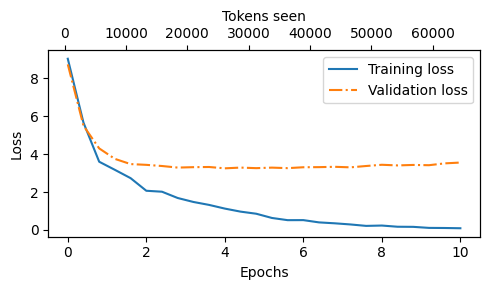

In [116]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()  # 1
    ax2.plot(tokens_seen, train_losses, alpha=0)  # 2
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)
# 1 Creates a second x-axis that shares the same y-axis
# 2 Invisible plot for aligning ticks

##### decoding strategies to control randomness

In [121]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_fe

In [122]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you) TABLETS (PT:10022891] NNMQ:99999033,99999086 SMQ


In [130]:
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))
# the mode, generates the same output, just taking the tokens with most percentage all the time

Output text:
 Every effort moves you!!!!!!!!!!!!!!!!!!!!!!!!!


In [ ]:
# ### ===>>> temperature scaling - a technique that adds a probabilistic selection process to the next-token generation task,
# allowing for more diverse and creative outputs by adjusting the "temperature" parameter that controls the randomness of the predictions.

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=1000,
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=1000,
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you!!!!!!!!!!!!!!!!!!!!!!!!!
Output text:
 Every effort moves you!!!!!!!!!!!!!!!!!!!!!!!!!


In [131]:
# ### ===>>> Top-k sampling - when combined with probabilistic sampling and temperature scaling, can improve the text generation results.
# In top-k sampling, we can restrict the sampled tokens to the top-k most likely tokens and exclude all other tokens from the selection process
# by masking their probability scores
# The top-k approach replaces all nonselected logits with negative infinity value (-inf), such that when computing the softmax values,
# the probability scores of the non-top-k tokens are 0, and the remaining probabilities sum up to 1

# creating a new function to generate text...


def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):  # 1
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        if top_k is not None:  # 2
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)
        if temperature > 0.0:  # 3
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:  # 4
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:  # 5
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


# 1 The for loop is the same as before: gets logits and only focuses on the last time step.
# 2 Filters logits with top_k sampling
# 3 Applies temperature scaling
# 4 Carries out greedy next-token selection as before when temperature scaling is disabled
# 5 Stops generating early if end-of-sequence token is encountered

In [132]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4,
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you,99999088,99999103,99999093,99


#### Loading and saving model weights in PyTorch